In [48]:
import pandas as pd

# Load datasets
files = {
    "budget": "../data/budget/Budget.csv",
    
    # Transactions
    "transactions_raw": "../data/transactions/personal finance data.csv",
    "transactions_clean": "../data/transactions/Personal_Finance_Dataset.csv",
    "transactions_labeled": "../data/transactions/personal_transactions.csv",
    
    # Profile / user-level finance
    "finance_expenses": "../data/profile/personal_finance_expenses.csv",
    "finance_tracker": "../data/profile/personal_finance_tracker_dataset.csv",
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

# Show quick info
for name, df in dfs.items():
    print(f"\n===== {name.upper()} =====")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:\n", df.isnull().sum())
    print(df.head(3))



===== BUDGET =====
Shape: (19, 2)
Columns: ['Category', 'Budget']
Missing values:
 Category    0
Budget      0
dtype: int64
         Category  Budget
0  Alcohol & Bars      50
1  Auto Insurance      75
2    Coffee Shops      15

===== TRANSACTIONS_RAW =====
Shape: (225, 6)
Columns: ['Date / Time', 'Mode', 'Category', 'Sub category', 'Income/Expense', 'Debit/Credit']
Missing values:
 Date / Time       0
Mode              0
Category          0
Sub category      0
Income/Expense    0
Debit/Credit      0
dtype: int64
                Date / Time                  Mode   Category Sub category  \
0  Friday, January 01, 2021  CUB - online payment  Allowance     From dad   
1  Friday, January 01, 2021  CUB - online payment       Food       Snacks   
2  Sunday, January 03, 2021  CUB - online payment      Other     From dad   

  Income/Expense  Debit/Credit  
0         Income        8000.0  
1        Expense          85.0  
2         Income         500.0  

===== TRANSACTIONS_CLEAN =====
Shape: 

In [7]:
df_budget = dfs["budget"]
print(df_budget.info())
print(df_budget.describe())
print(df_budget.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  19 non-null     object
 1   Budget    19 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes
None
            Budget
count    19.000000
mean    123.736842
std     245.517106
min       0.000000
25%      15.000000
50%      65.000000
75%     125.000000
max    1100.000000
                 Category  Budget
0          Alcohol & Bars      50
1          Auto Insurance      75
2            Coffee Shops      15
3  Electronics & Software       0
4           Entertainment      25


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = ['#1f77b4' if i >= 3 else '#ff7f0e' for i in range(len(data))]

plt.figure(figsize=(12, 6))
sns.barplot(x="Budget", y="Category", data=data, palette=colors)
plt.title("Budget Allocation by Category (Top 3 Highlighted)")
plt.xlabel("Budget Amount")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(data["Budget"], labels=data["Category"], autopct="%1.1f%%", startangle=140)
plt.title("Budget Allocation by Category")
plt.axis("equal")
plt.tight_layout()
plt.show()


NameError: name 'data' is not defined

In [ ]:
df_trx_raw = dfs["transactions_raw"]
print(df_trx_raw.info())
print(df_trx_raw.describe(include='all'))
print(df_trx_raw.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date / Time     225 non-null    object 
 1   Mode            225 non-null    object 
 2   Category        225 non-null    object 
 3   Sub category    225 non-null    object 
 4   Income/Expense  225 non-null    object 
 5   Debit/Credit    225 non-null    float64
dtypes: float64(1), object(5)
memory usage: 10.7+ KB
None
                   Date / Time                  Mode Category Sub category  \
count                      225                   225      225          225   
unique                     111                     1       10          134   
top     Saturday, May 01, 2021  CUB - online payment     Food       office   
freq                         7                   225      114           12   
mean                       NaN                   NaN      NaN          NaN   
std       

In [ ]:
# Convert dates and separate Income/Expense
df_raw = dfs["transactions_raw"].copy()
df_raw['Date'] = pd.to_datetime(df_raw['Date / Time'], errors='coerce')
df_raw['Type'] = df_raw['Income/Expense'].str.lower()

# Normalize category ( Salary and salary)
df_raw["Category"] = df_raw["Category"].str.strip().str.title()

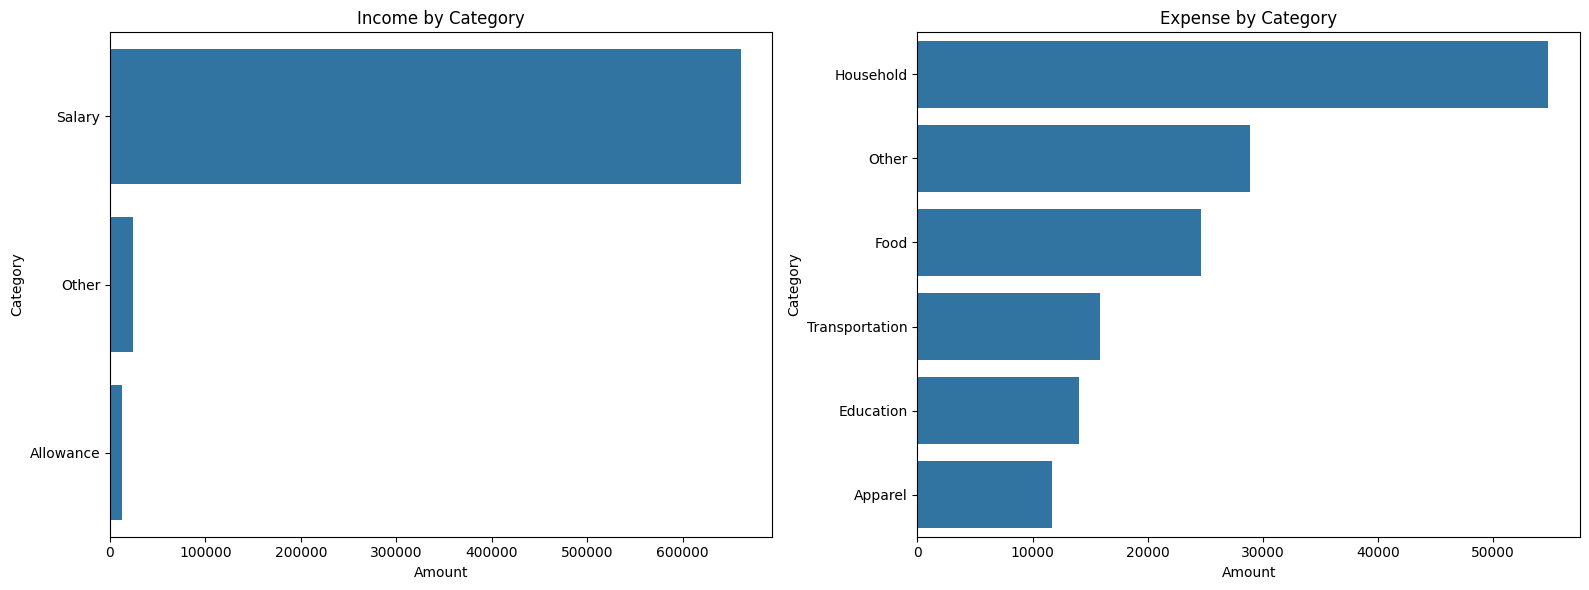

In [ ]:
# Total Amount by Category
income_df = df_raw[df_raw['Type'] == 'income']
expense_df = df_raw[df_raw['Type'] == 'expense']

# Total income and expense by category
income_totals = income_df.groupby("Category")["Debit/Credit"].sum().sort_values(ascending=False)
expense_totals = expense_df.groupby("Category")["Debit/Credit"].sum().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=income_totals.values, y=income_totals.index, ax=ax[0])
ax[0].set_title("Income by Category")
ax[0].set_xlabel("Amount")

sns.barplot(x=expense_totals.values, y=expense_totals.index, ax=ax[1])
ax[1].set_title("Expense by Category")
ax[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()


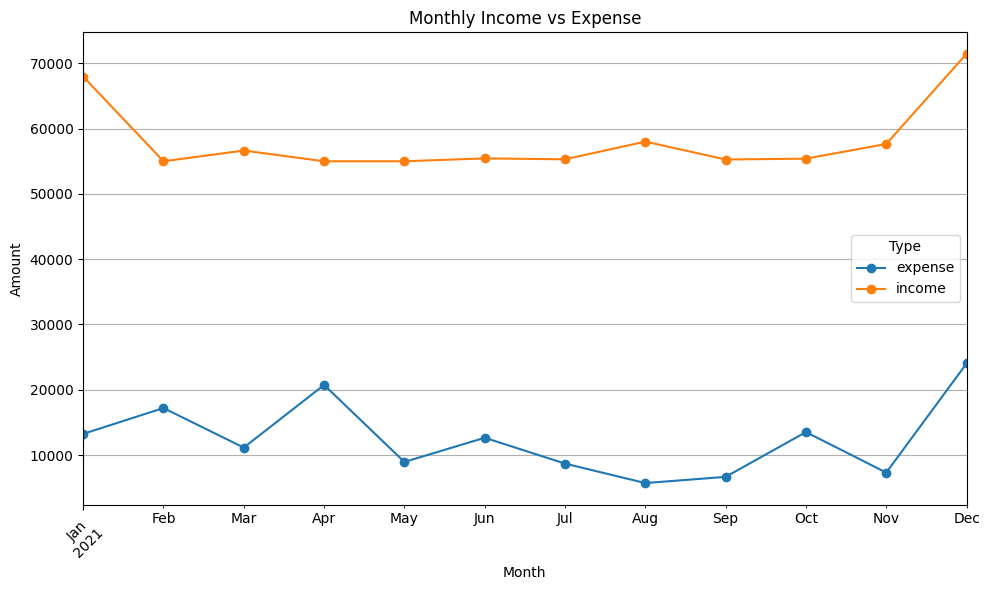

In [ ]:
# Monthly trend
df_raw['Month'] = df_raw['Date'].dt.to_period("M")
monthly = df_raw.groupby(['Month', 'Type'])["Debit/Credit"].sum().unstack().fillna(0)

monthly.plot(kind="line", figsize=(10,6), marker='o')
plt.title("Monthly Income vs Expense")
plt.ylabel("Amount")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


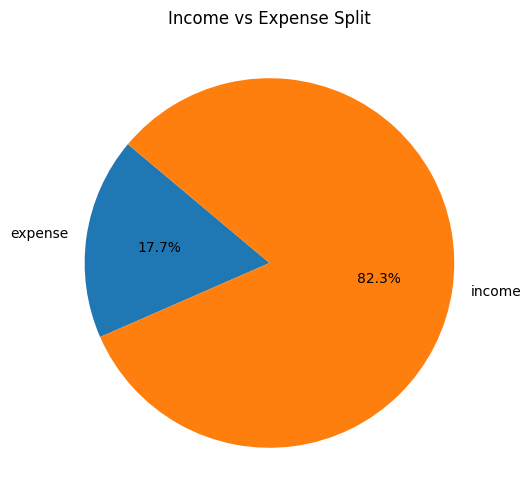

In [ ]:
# Income vs Expense 
plt.figure(figsize=(6, 6))
df_raw.groupby("Type")["Debit/Credit"].sum().plot(kind="pie", autopct='%1.1f%%', startangle=140)
plt.title("Income vs Expense Split")
plt.ylabel("")
plt.show()

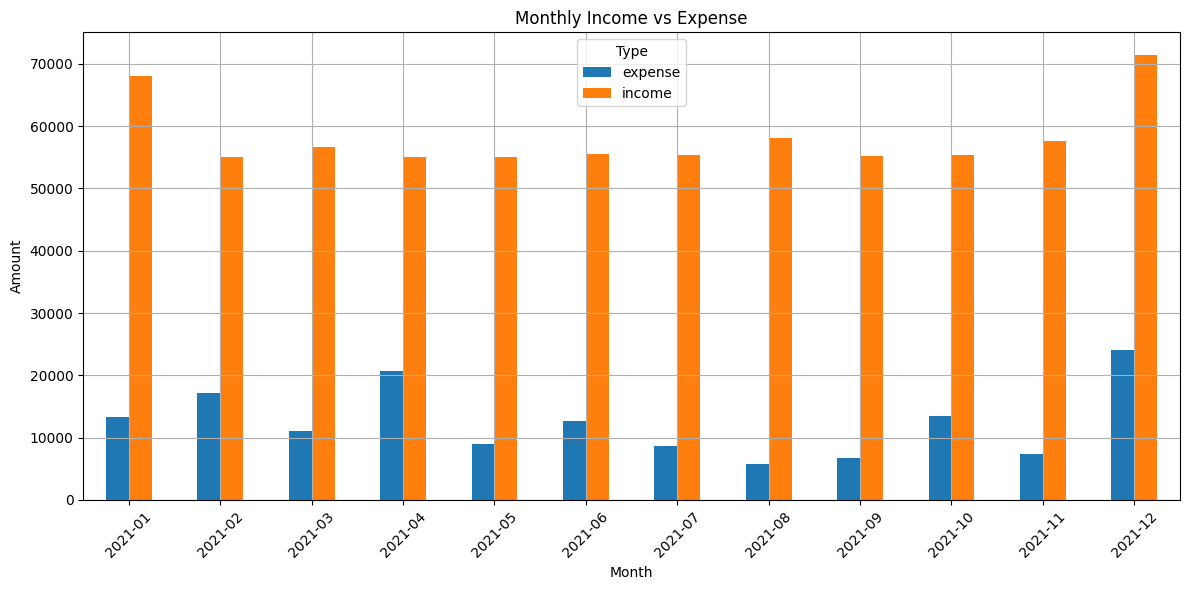

In [ ]:
# Monthly Income vs Expense Trend

monthly_totals = df_raw.groupby([df_raw['Date'].dt.to_period("M"), "Type"])["Debit/Credit"].sum().unstack().fillna(0)

monthly_totals.plot(kind="bar", stacked=False, figsize=(12,6))
plt.title("Monthly Income vs Expense")
plt.ylabel("Amount")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


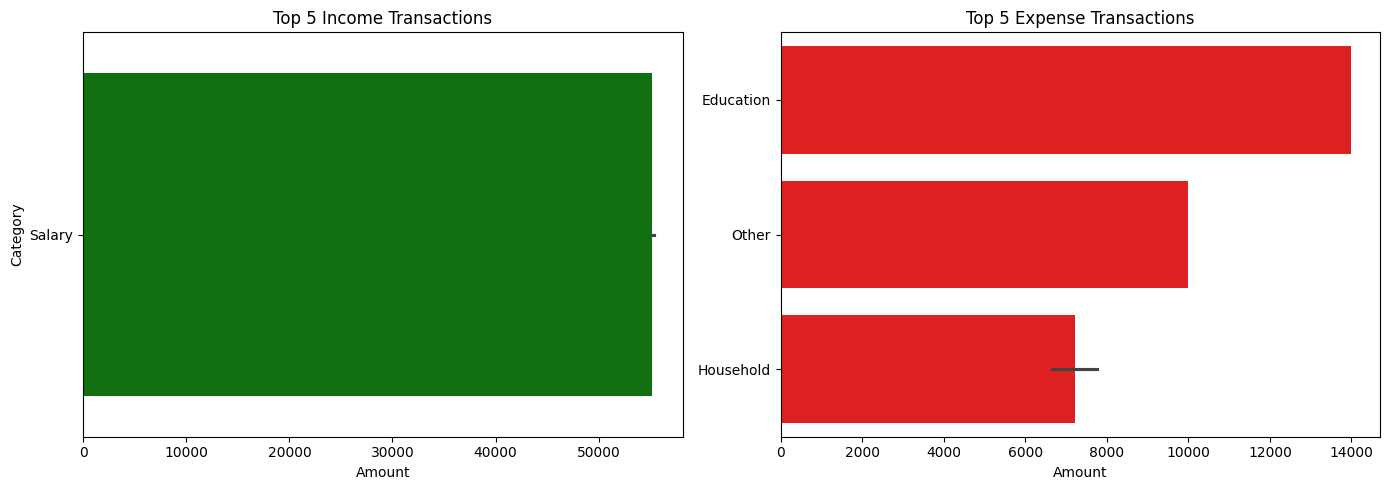

In [ ]:
# Top 5 Income and Expenses.

top_income = df_raw[df_raw['Type'] == 'income'].nlargest(5, 'Debit/Credit')
top_expense = df_raw[df_raw['Type'] == 'expense'].nlargest(5, 'Debit/Credit')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

sns.barplot(x='Debit/Credit', y='Category', data=top_income, ax=axes[0], color='green')
axes[0].set_title("Top 5 Income Transactions")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Category")

sns.barplot(x='Debit/Credit', y='Category', data=top_expense, ax=axes[1], color='red')
axes[1].set_title("Top 5 Expense Transactions")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


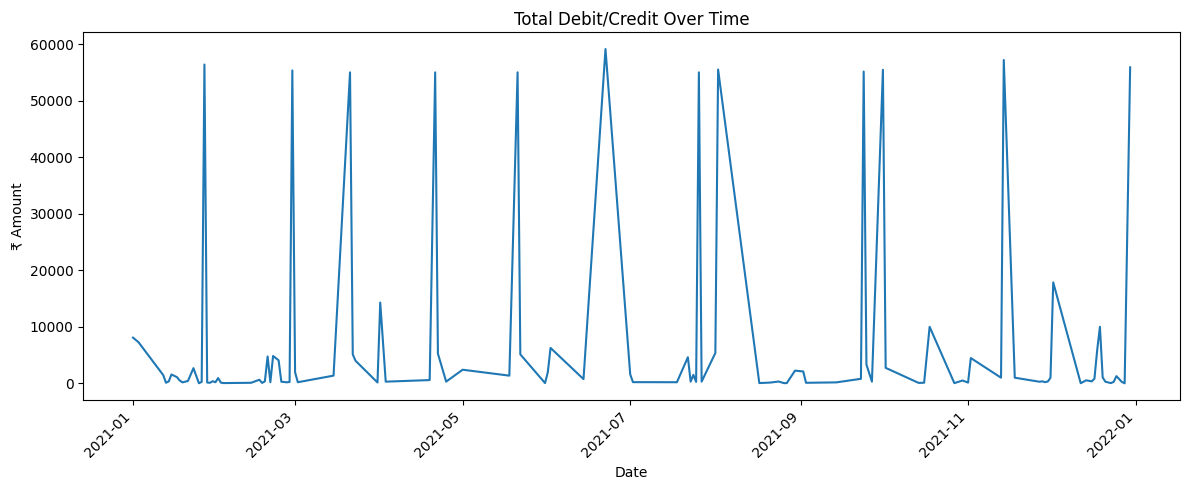

In [ ]:
# Transactions over time.

plt.figure(figsize=(12, 5))
df_raw.groupby("Date")["Debit/Credit"].sum().plot()
plt.title("Total Debit/Credit Over Time")
plt.xlabel("Date")
plt.ylabel("₹ Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


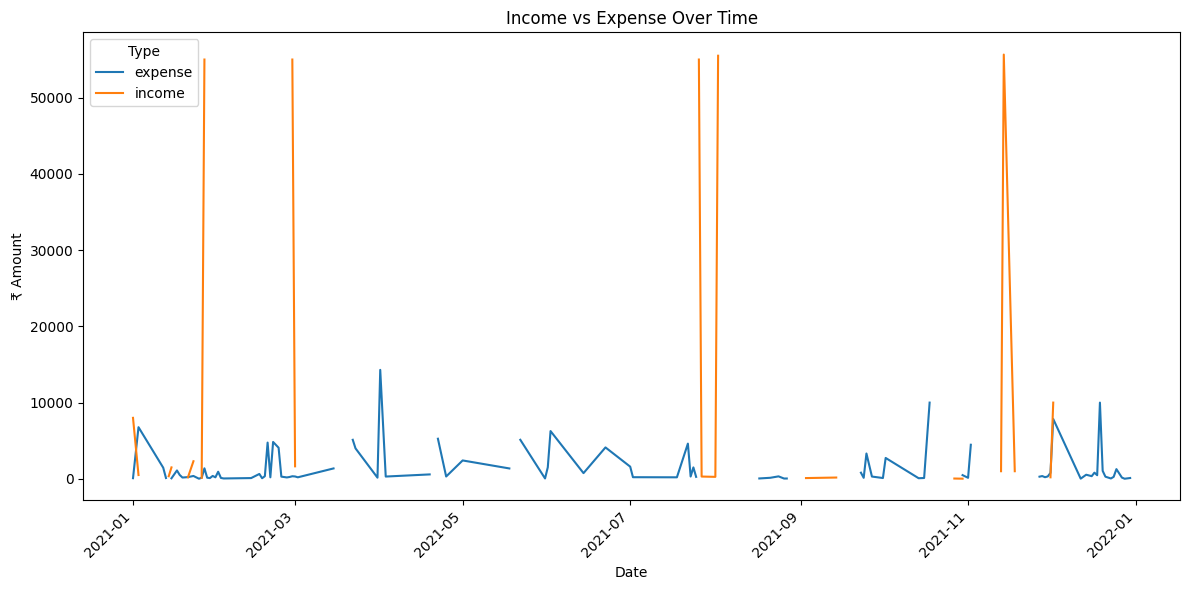

In [ ]:
# Split Income vs Expense over Time

df_raw.groupby(["Date", "Type"])["Debit/Credit"].sum().unstack().plot(figsize=(12,6))
plt.title("Income vs Expense Over Time")
plt.xlabel("Date")
plt.ylabel("₹ Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


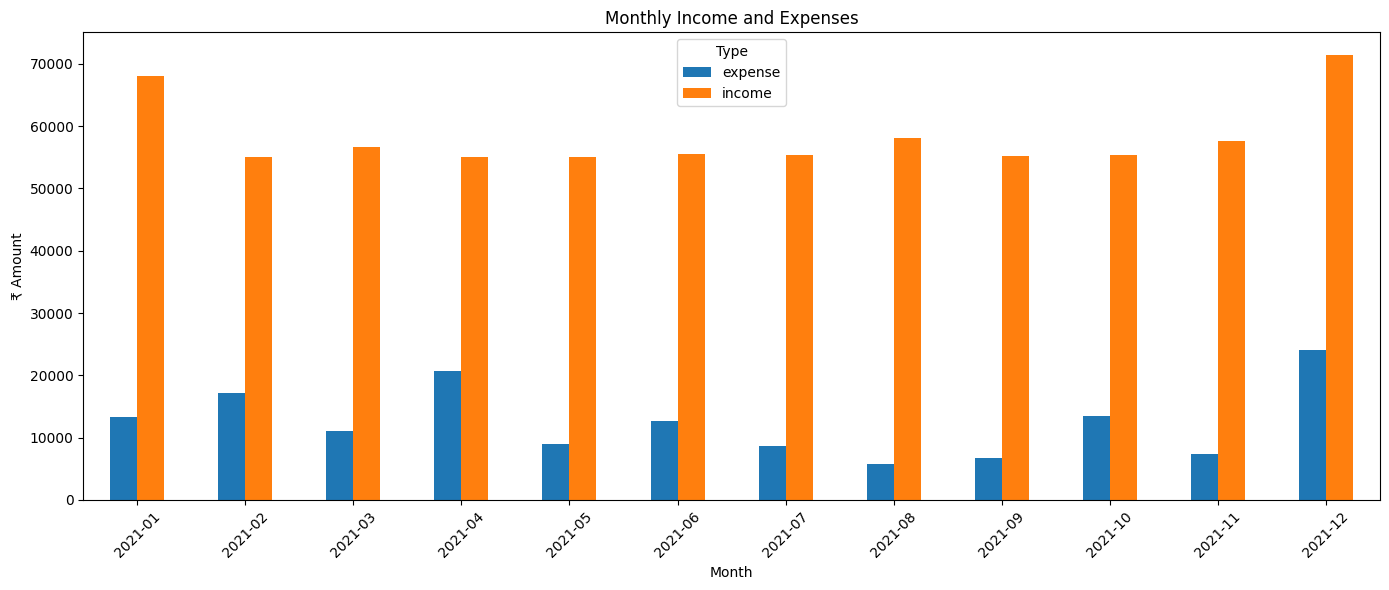

In [ ]:
# Monthly Aggregates 

df_raw['Month'] = df_raw['Date'].dt.to_period("M")
monthly_summary = df_raw.groupby(["Month", "Type"])["Debit/Credit"].sum().unstack()

monthly_summary.plot(kind='bar', stacked=False, figsize=(14,6))
plt.title("Monthly Income and Expenses")
plt.xlabel("Month")
plt.ylabel("₹ Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
df_trx_clean = dfs["transactions_clean"]
print(df_trx_clean.info())
print(df_trx_clean.describe())
print(df_trx_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB
None
            Amount
count  1500.000000
mean   1307.520913
std     982.283361
min      14.370000
25%     629.340000
50%    1156.285000
75%    1712.932500
max    4996.000000
         Date                   Transaction Description      Category  \
0  2020-01-02                               Score each.  Food & Drink   
1  2020-01-02                       Quality throughout.     Utilities   
2  2020-01-04        Instead ahead despite measure ago.          Ren

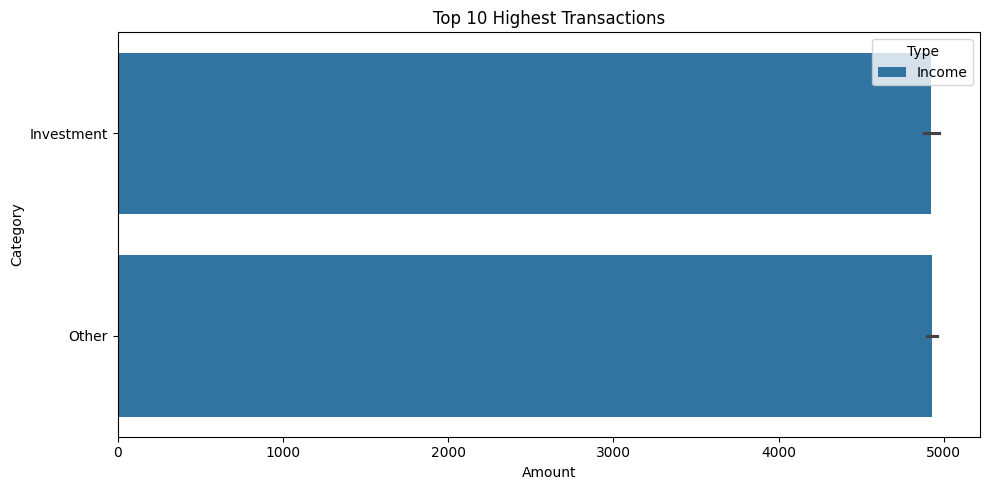

In [10]:
# Top 10 Highest Transactions

top_txns = df_trx_clean.sort_values("Amount", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x="Amount", y="Category", data=top_txns, hue="Type")
plt.title("Top 10 Highest Transactions")
plt.xlabel("Amount")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


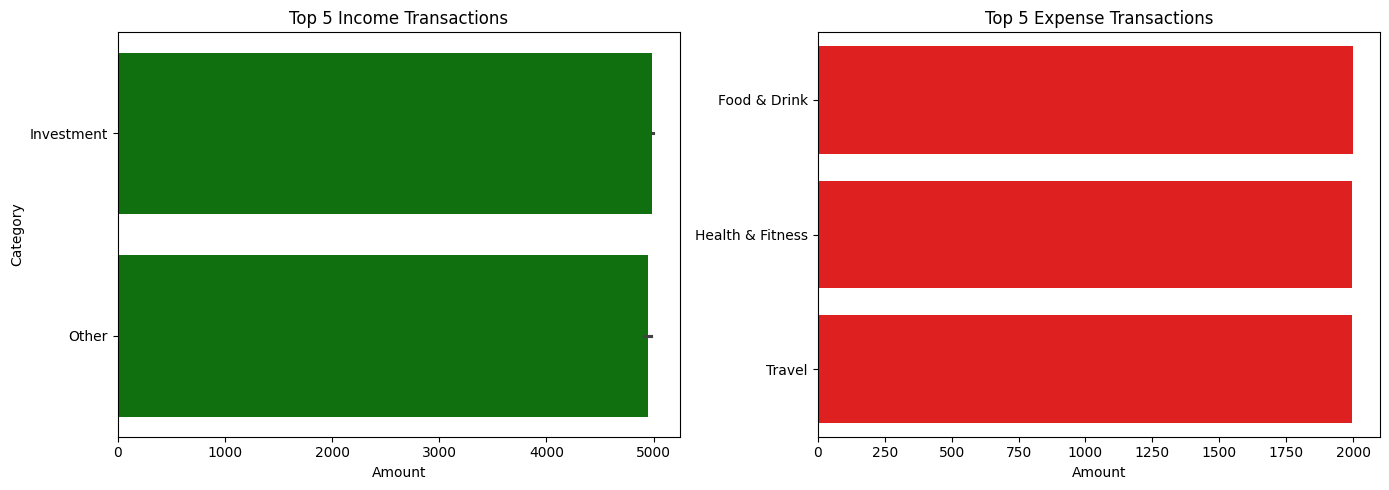

In [11]:
# Top 5 Income & Expense Transactions

top_income = df_trx_clean[df_trx_clean["Type"] == "Income"].nlargest(5, "Amount")
top_expense = df_trx_clean[df_trx_clean["Type"] == "Expense"].nlargest(5, "Amount")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

sns.barplot(x="Amount", y="Category", data=top_income, ax=axes[0], color='green')
axes[0].set_title("Top 5 Income Transactions")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Category")

sns.barplot(x="Amount", y="Category", data=top_expense, ax=axes[1], color='red')
axes[1].set_title("Top 5 Expense Transactions")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


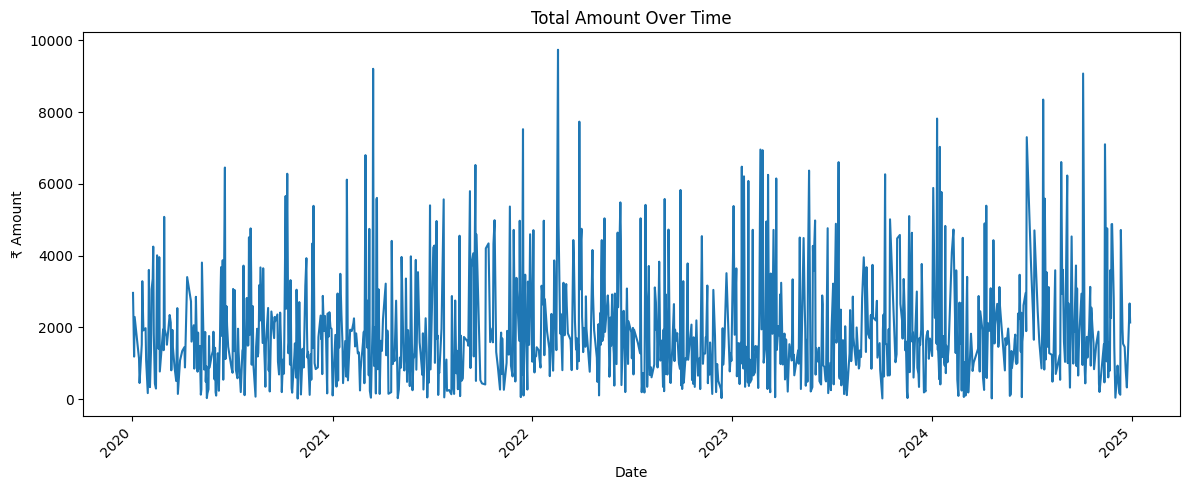

In [12]:
# Total Amount over time.

df_trx_clean['Date'] = pd.to_datetime(df_trx_clean['Date'])

plt.figure(figsize=(12, 5))
df_trx_clean.groupby("Date")["Amount"].sum().plot()
plt.title("Total Amount Over Time")
plt.xlabel("Date")
plt.ylabel("₹ Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


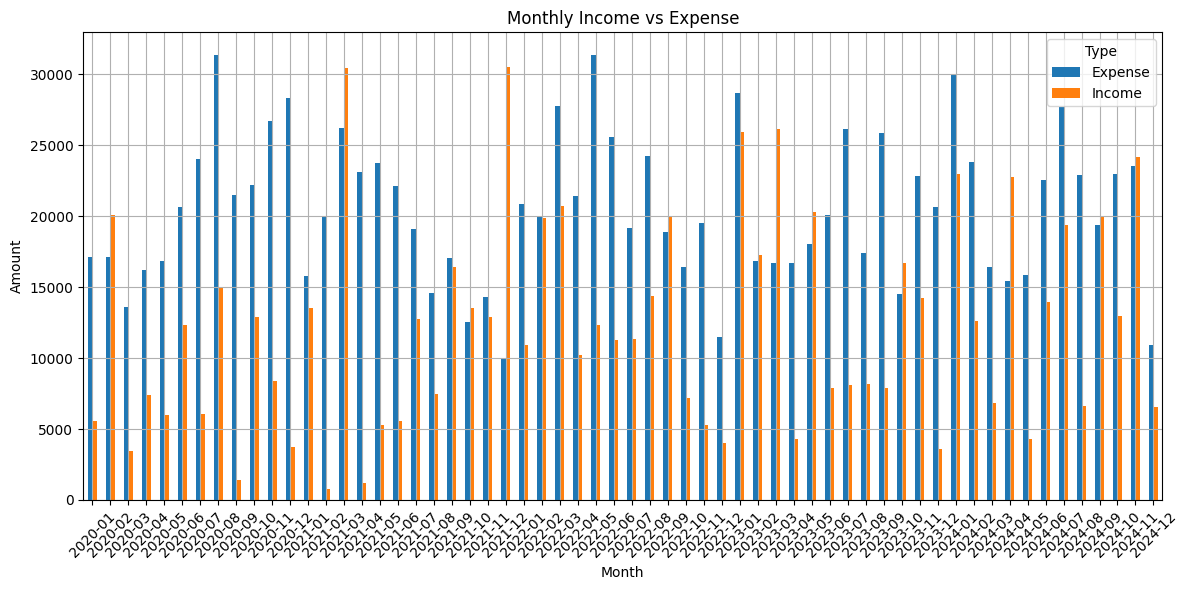

In [13]:
# Monthly Income vs Expense (Bar Chart)

df_trx_clean['Month'] = df_trx_clean['Date'].dt.to_period("M")
monthly_totals = df_trx_clean.groupby(["Month", "Type"])["Amount"].sum().unstack().fillna(0)

monthly_totals.plot(kind="bar", stacked=False, figsize=(12,6))
plt.title("Monthly Income vs Expense")
plt.ylabel("Amount")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


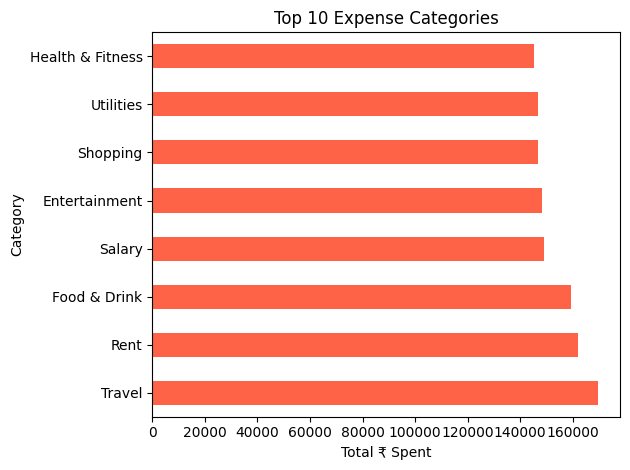

In [14]:
# Top spending totals

df_trx_clean[df_trx_clean['Type'] == 'Expense'] \
    .groupby("Category")["Amount"].sum() \
    .sort_values(ascending=False).head(10) \
    .plot(kind='barh', color='tomato')

plt.title("Top 10 Expense Categories")
plt.xlabel("Total ₹ Spent")
plt.tight_layout()
plt.show()

In [15]:
df_trx_labeled = dfs["transactions_labeled"]
print(df_trx_labeled.info())
print(df_trx_labeled.describe(include='all'))
print(df_trx_labeled.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              806 non-null    object 
 1   Description       806 non-null    object 
 2   Amount            806 non-null    float64
 3   Transaction Type  806 non-null    object 
 4   Category          806 non-null    object 
 5   Account Name      806 non-null    object 
dtypes: float64(1), object(5)
memory usage: 37.9+ KB
None
              Date          Description       Amount Transaction Type  \
count          806                  806   806.000000              806   
unique         432                   65          NaN                2   
top     12/18/2018  Credit Card Payment          NaN            debit   
freq             7                  143          NaN              688   
mean           NaN                  NaN   273.391489              NaN   
std            NaN      

Index(['Date', 'Description', 'Amount', 'Transaction Type', 'Category',
       'Account Name'],
      dtype='object')


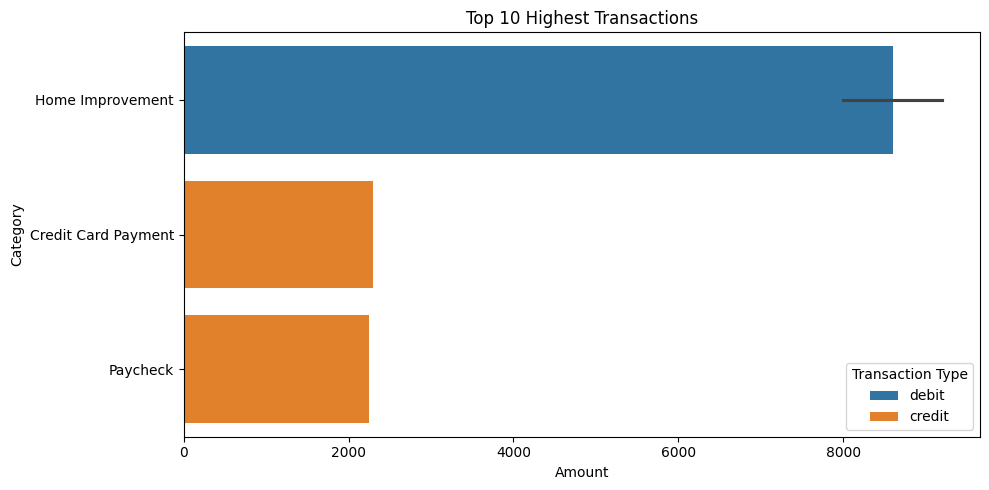

In [18]:
# Top 10 Highest Transactions

top_txns = df_trx_labeled.sort_values("Amount", ascending=False).head(10)

print(df_trx_labeled.columns)

plt.figure(figsize=(10, 5))
sns.barplot(x="Amount", y="Category", data=top_txns, hue="Transaction Type")
plt.title("Top 10 Highest Transactions")
plt.xlabel("Amount")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [23]:
print(df_trx_labeled["Transaction Type"].unique())

# Check how many rows fall into Income/Expense
print("Income rows:", df_trx_labeled[df_trx_labeled["Transaction Type"] == "Income"].shape[0])
print("Expense rows:", df_trx_labeled[df_trx_labeled["Transaction Type"] == "Expense"].shape[0])

# Just to be safe — check for missing values
print(df_trx_labeled["Transaction Type"].isna().sum())

['debit' 'credit']
Income rows: 0
Expense rows: 0
0


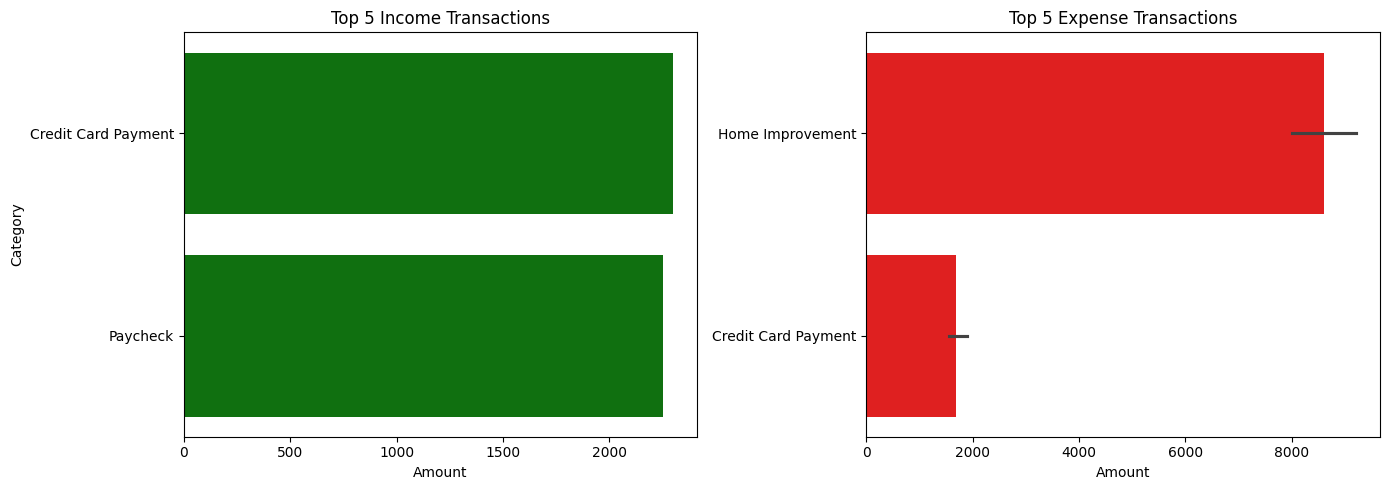

In [25]:
# 💰 2. Top 5 Income & Expense Transactions

df_trx_labeled["Transaction Type"] = df_trx_labeled["Transaction Type"].map({
    "credit": "Income",
    "debit": "Expense"
})

top_income = df_trx_labeled[df_trx_labeled["Transaction Type"] == "Income"].nlargest(5, "Amount")
top_expense = df_trx_labeled[df_trx_labeled["Transaction Type"] == "Expense"].nlargest(5, "Amount")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

sns.barplot(x="Amount", y="Category", data=top_income, ax=axes[0], color='green')
axes[0].set_title("Top 5 Income Transactions")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Category")

sns.barplot(x="Amount", y="Category", data=top_expense, ax=axes[1], color='red')
axes[1].set_title("Top 5 Expense Transactions")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


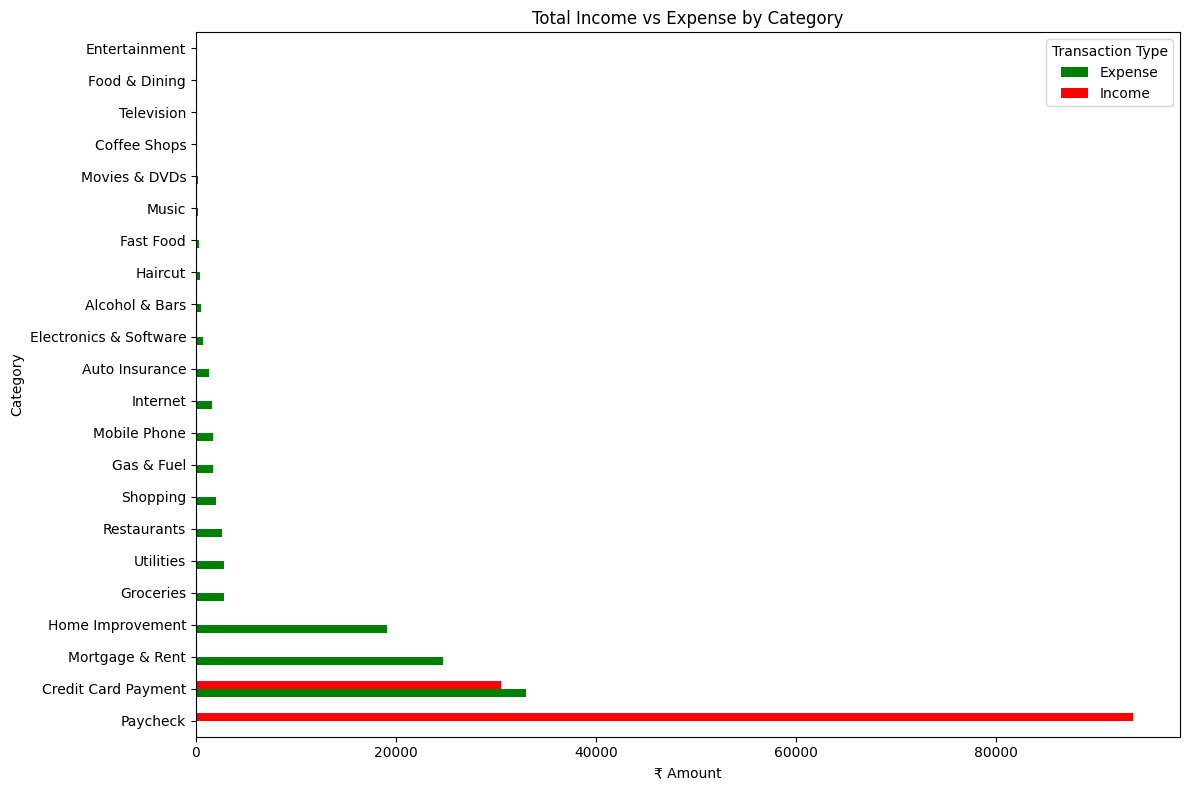

In [26]:
# Category-wise Distribution
# Group by Category and Transaction Type, sum amounts

category_summary = df_trx_labeled.groupby(["Category", "Transaction Type"])["Amount"].sum().unstack().fillna(0)

# Sort by total amount (Income + Expense)
category_summary["Total"] = category_summary.sum(axis=1)
category_summary = category_summary.sort_values("Total", ascending=False).drop(columns="Total")

# Plot
category_summary.plot(kind="barh", figsize=(12, 8), color=["green", "red"])
plt.title("Total Income vs Expense by Category")
plt.xlabel("₹ Amount")
plt.ylabel("Category")
plt.legend(title="Transaction Type")
plt.tight_layout()
plt.show()

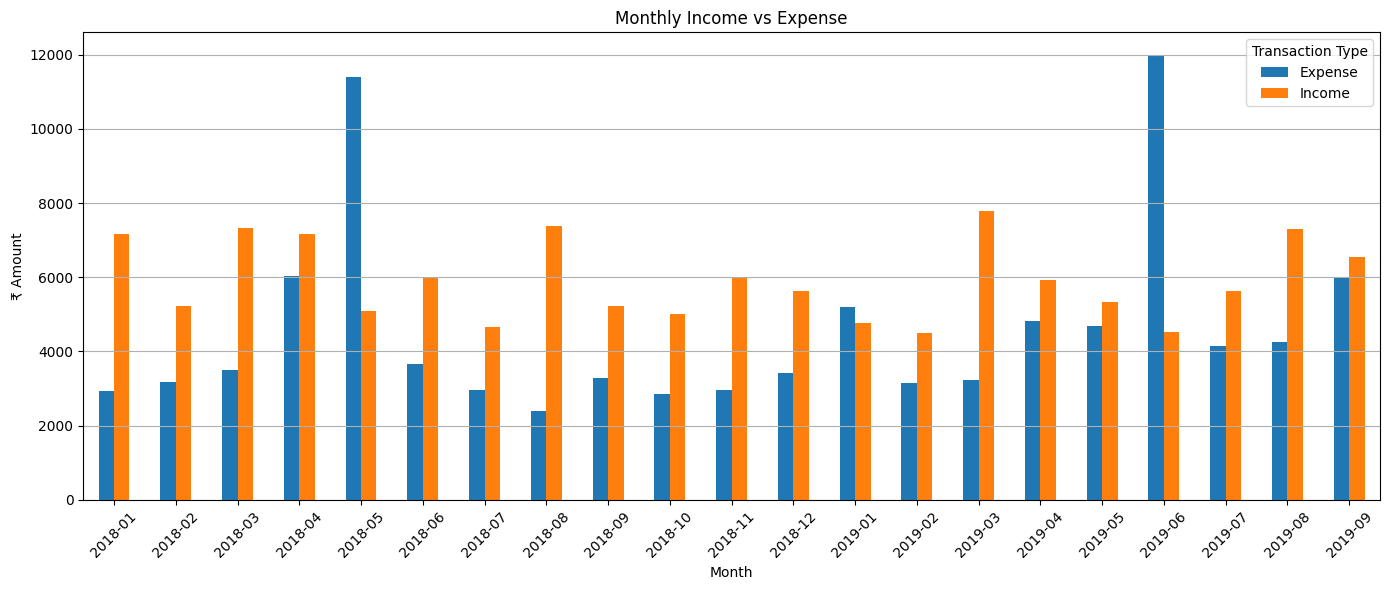

In [27]:
# Monthly Income vs Expense Trend

# Convert 'Date' column to datetime and extract Month
df_trx_labeled["Month"] = pd.to_datetime(df_trx_labeled["Date"]).dt.to_period("M")

# Group by Month and Transaction Type
monthly_trend = df_trx_labeled.groupby(["Month", "Transaction Type"])["Amount"].sum().unstack().fillna(0)

# Plot
monthly_trend.plot(kind="bar", figsize=(14, 6))
plt.title("Monthly Income vs Expense")
plt.xlabel("Month")
plt.ylabel("₹ Amount")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


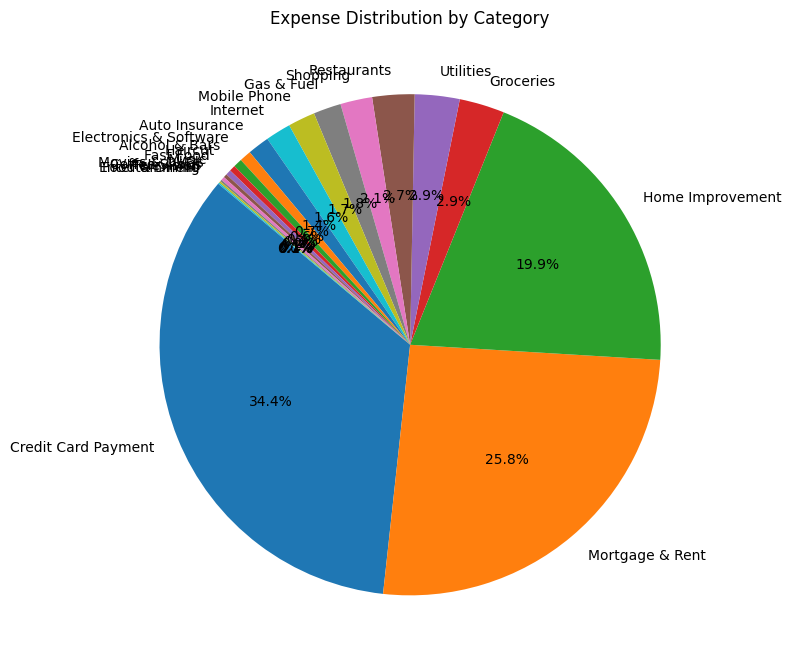

In [28]:
# Category wise spending
# Filter only Expenses
expense_data = df_trx_labeled[df_trx_labeled["Transaction Type"] == "Expense"]

# Group and sum by Category
category_expense = expense_data.groupby("Category")["Amount"].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 8))
category_expense.plot(kind="pie", autopct='%1.1f%%', startangle=140)
plt.title("Expense Distribution by Category")
plt.ylabel("")  # Hide y-axis label
plt.tight_layout()
plt.show()


In [30]:
df_expenses = dfs["finance_expenses"]
print(df_expenses.info())
print(df_expenses.describe().T)
print(df_expenses['Occupation'].value_counts())
print(df_expenses.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

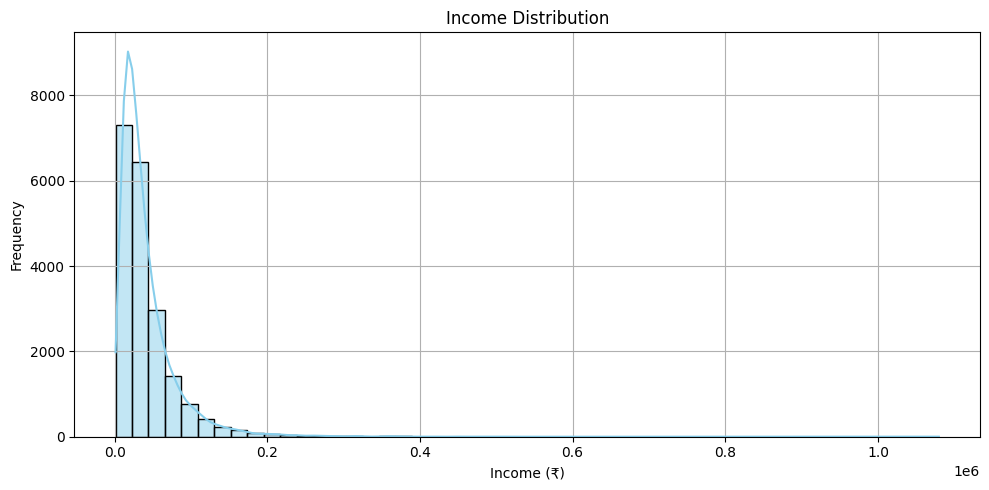

In [31]:
# Distribution of Income

plt.figure(figsize=(10, 5))
sns.histplot(df_expenses['Income'], bins=50, kde=True, color='skyblue')
plt.title("Income Distribution")
plt.xlabel("Income (₹)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

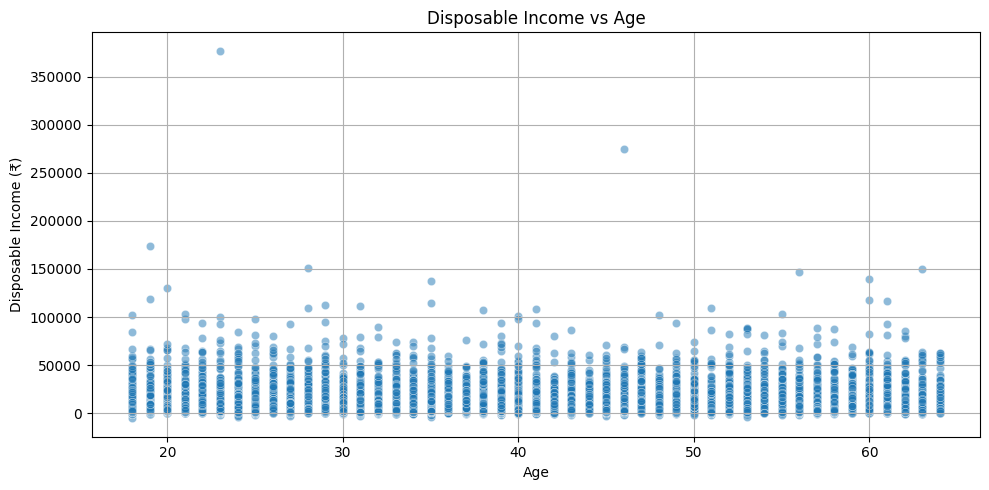

In [32]:
# Distribution of Income
# disposable income varies with age. It may help spot age groups with higher or lower financial flexibility.

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_expenses, x="Age", y="Disposable_Income", alpha=0.5)
plt.title("Disposable Income vs Age")
plt.xlabel("Age")
plt.ylabel("Disposable Income (₹)")
plt.grid(True)
plt.tight_layout()
plt.show()

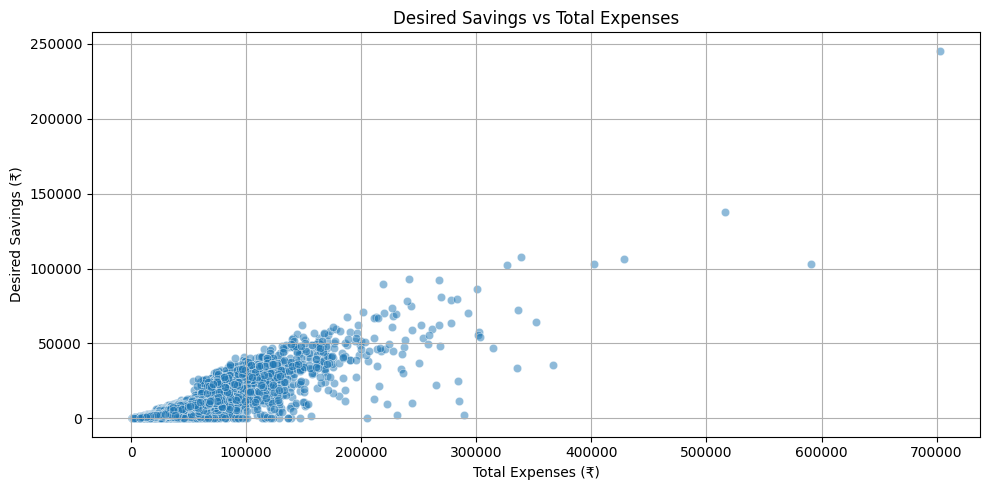

In [33]:
# Desired Savings vs Total Expenses

# Sum all expense categories for each row
expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
    "Eating_Out", "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous"
]
df_expenses["Total_Expenses"] = df_expenses[expense_cols].sum(axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_expenses, 
    x="Total_Expenses", 
    y="Desired_Savings", 
    alpha=0.5
)
plt.title("Desired Savings vs Total Expenses")
plt.xlabel("Total Expenses (₹)")
plt.ylabel("Desired Savings (₹)")
plt.grid(True)
plt.tight_layout()
plt.show()


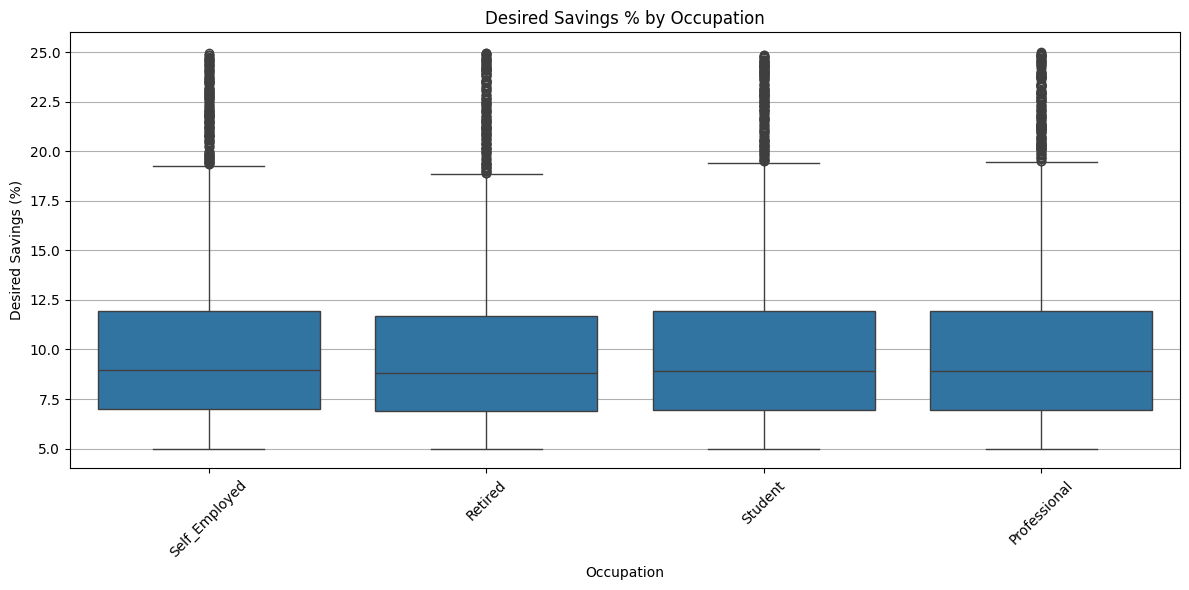

In [34]:
# Desired Savings % by Occupation (Box Plot)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_expenses, 
    x="Occupation", 
    y="Desired_Savings_Percentage"
)
plt.title("Desired Savings % by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Desired Savings (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()


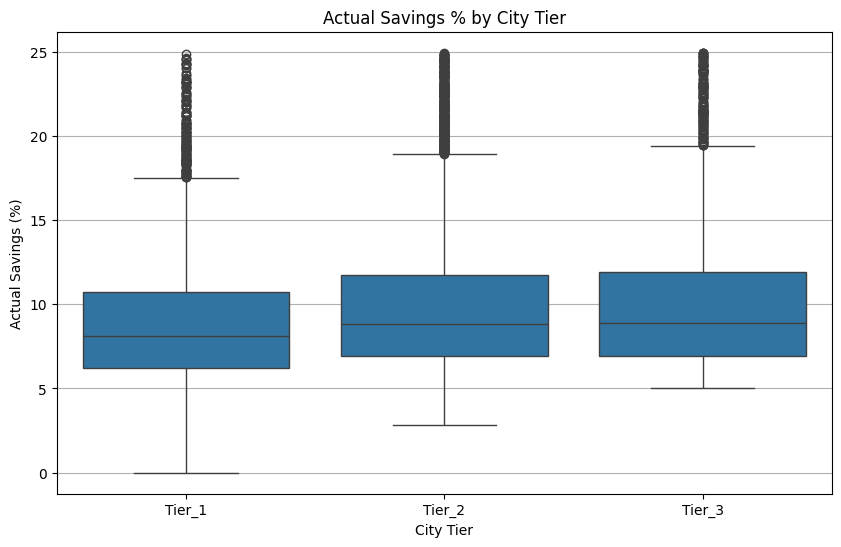

In [35]:
# Actual Savings % by City Tier (Box Plot)

# Calculate Actual Savings % if not already present
if "Actual_Savings_Percentage" not in df_expenses.columns:
    df_expenses["Actual_Savings_Percentage"] = (
        df_expenses["Desired_Savings"] / df_expenses["Income"]
    ) * 100

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_expenses,
    x="City_Tier",
    y="Actual_Savings_Percentage"
)
plt.title("Actual Savings % by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Actual Savings (%)")
plt.grid(True, axis='y')
plt.show()


In [42]:
df_tracker = dfs["finance_tracker"]
print(df_tracker.columns)
print(df_tracker.info())
print(df_tracker.describe().T)
print(df_tracker['income_type'].value_counts())
print(df_tracker.head())



Index(['date', 'user_id', 'monthly_income', 'monthly_expense_total',
       'savings_rate', 'budget_goal', 'financial_scenario', 'credit_score',
       'debt_to_income_ratio', 'loan_payment', 'investment_amount',
       'subscription_services', 'emergency_fund', 'transaction_count',
       'fraud_flag', 'discretionary_spending', 'essential_spending',
       'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status',
       'financial_advice_score', 'financial_stress_level', 'actual_savings',
       'savings_goal_met'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   object 
 1   user_id                 3000 non-null   int64  
 2   monthly_income          3000 non-null   float64
 3   monthly_expense_total   3000 non-null   float64
 4   savings_rate    

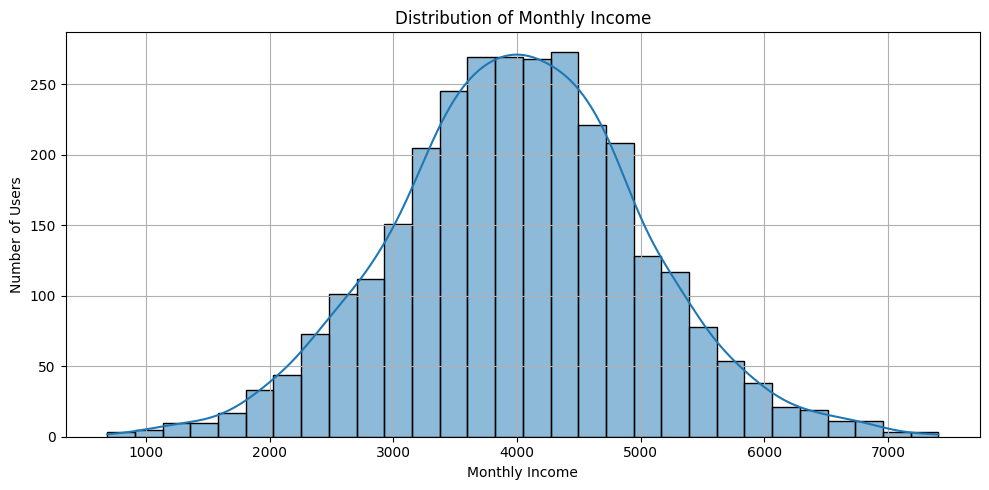

In [38]:
# Distribution of Monthly Income

plt.figure(figsize=(10, 5))
sns.histplot(df_tracker["monthly_income"], kde=True, bins=30)
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Users")
plt.grid(True)
plt.tight_layout()
plt.show()


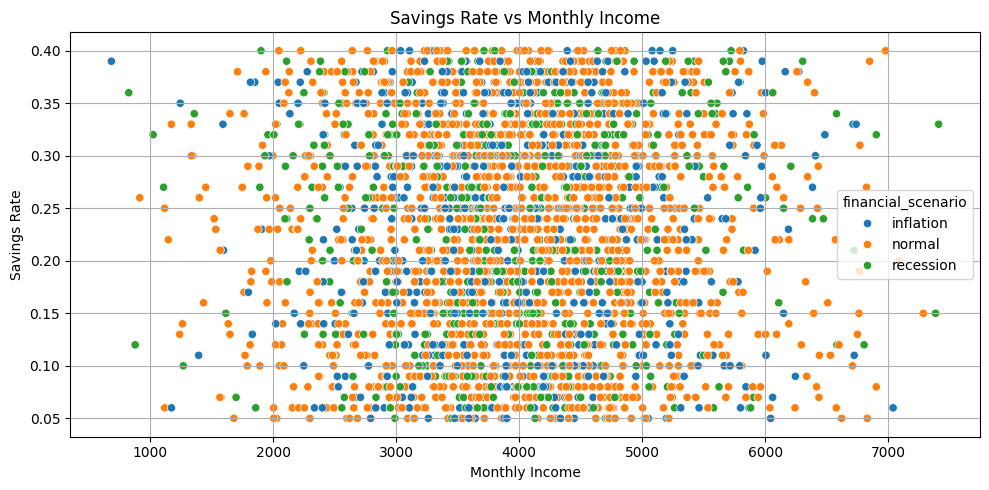

In [39]:
# Savings Rate vs. Monthly Income

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_tracker, x="monthly_income", y="savings_rate", hue="financial_scenario")
plt.title("Savings Rate vs Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Savings Rate")
plt.grid(True)
plt.tight_layout()
plt.show()


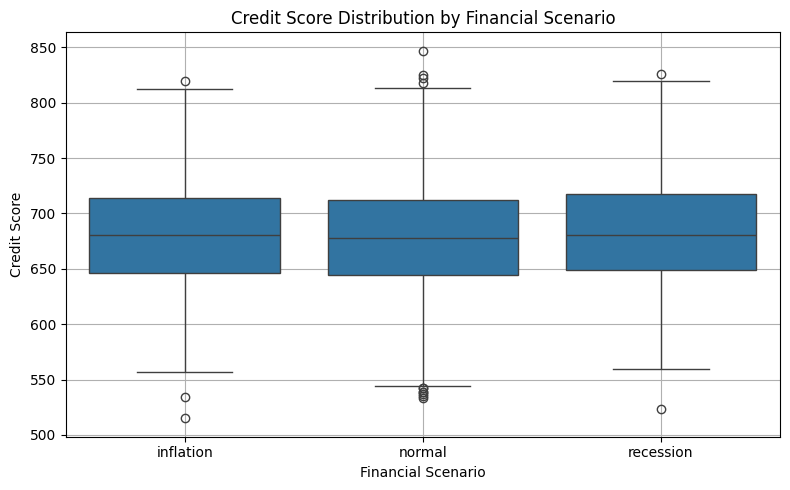

In [43]:
# Credit Score by Risk Profile

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tracker, x="financial_scenario", y="credit_score")
plt.title("Credit Score Distribution by Financial Scenario")
plt.xlabel("Financial Scenario")
plt.ylabel("Credit Score")
plt.grid(True)
plt.tight_layout()
plt.show()


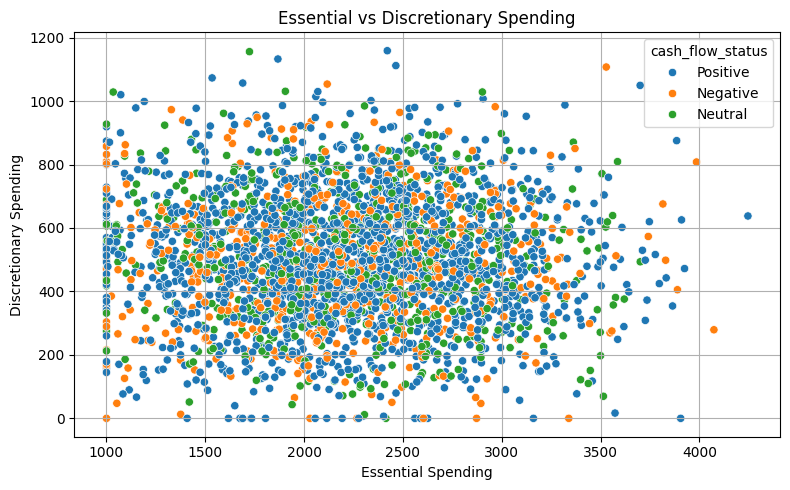

In [44]:
# Essential vs Discretionary Spending

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_tracker,
                x="essential_spending",
                y="discretionary_spending",
                hue="cash_flow_status")
plt.title("Essential vs Discretionary Spending")
plt.xlabel("Essential Spending")
plt.ylabel("Discretionary Spending")
plt.grid(True)
plt.tight_layout()
plt.show()

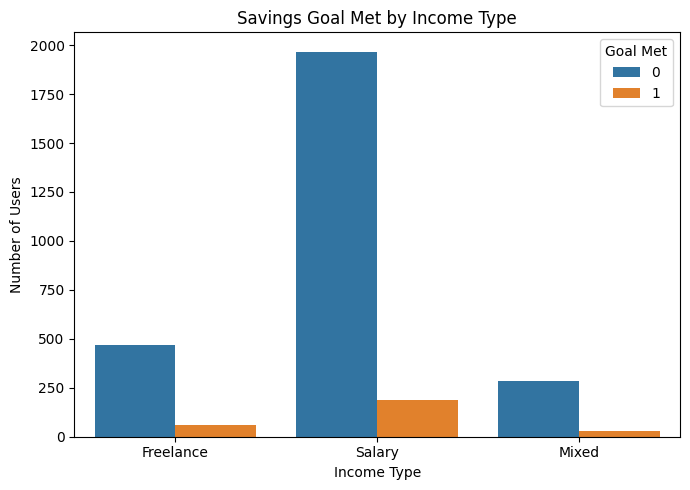

In [45]:
# Savings Goal Met by Income Type

plt.figure(figsize=(7, 5))
sns.countplot(data=df_tracker,
              x="income_type",
              hue="savings_goal_met")
plt.title("Savings Goal Met by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Number of Users")
plt.legend(title="Goal Met")
plt.tight_layout()
plt.show()